In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd
from scipy.interpolate import griddata

import sys
sys.path.append('../Zack/')
from zack_functions import find_bloom_phenological_indices

In [43]:
# For each pixel,
XX_SOCA, YY_SOCA = np.meshgrid((((360 + (data.longitude.values % 360)) % 360)), data.latitude.values)

In [44]:
oisst_path = '../../../gobgc26_example/data/mhw_mask_north_atlantic_final.nc'
oisst = xr.open_dataset(oisst_path,decode_times=False)

oisst_time = pd.date_range(start="1981-09-01", end="2026-08-17", freq="D")
oisst_time = np.array(date_range).astype('datetime64[D]')
oisst

<xarray.Dataset> Size: 1GB
Dimensions:   (time: 16422, lat: 260, lon: 332)
Coordinates:
  * time      (time) int64 131kB -9223372036854775806 ... -9223372036854775806
  * lat       (lat) float32 1kB 0.125 0.375 0.625 0.875 ... 64.38 64.62 64.88
  * lon       (lon) float32 1kB 277.1 277.4 277.6 277.9 ... 359.4 359.6 359.9
Data variables:
    mhw_mask  (time, lat, lon) int8 1GB ...

In [45]:
XX_MHW, YY_MHW = np.meshgrid(oisst.lon.values, oisst.lat.values)
points = (XX_MHW.flatten(), YY_MHW.flatten())

mhw = griddata(points, oisst.mhw_mask.values[-1,:,:].flatten(), 
               (XX_SOCA, YY_SOCA), method='nearest').reshape(XX_SOCA.shape)
mhw = mhw.reshape(XX_SOCA.shape)

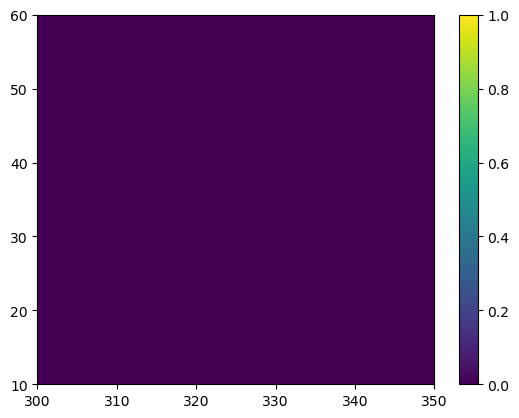

In [46]:
plt.pcolormesh(XX_SOCA, YY_SOCA, mhw, vmin =0, vmax = 1)
plt.colorbar()

In [64]:
year = 2022
flist = sorted(glob.glob(soca_dir+'cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_'+str(int(year))+'*_'+soca_version+'.nc'))
flist

['/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220105T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220112T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220119T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220126T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220202T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220209T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220216T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicus/bgc-chl-poc/cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_20220223T0000Z_P202511.nc',
 '/Volumes/FATDATABABY/copernicu

In [6]:
# Load biome flags
biomes = xr.open_dataset('biomes_2010_2025.nc')
biomes.close()

XX_biome, YY_biome = np.meshgrid(biomes.lon.values, biomes.lat.values)
points = (XX_biome.flatten(), YY_biome.flatten())

# pheno columns
var_names = ['PRES', 'TEMP', 'PSAL', 'DOXY', 'CHLA', 'BBP700', 'LATITUDE', 'LONGITUDE', 'JULD']
columns = ['BLOOM_MAXIMUM', 'BLOOM_INITIATION_TS', 'BLOOM_TERMINATION_TS', 'BLOOM_DURATION_TS',
       'BLOOM_INITIATION_TS_DATE', 'BLOOM_TERMINATION_TS_DATE',
       'BLOOM_INITIATION_CS', 'BLOOM_TERMINATION_CS', 'BLOOM_DURATION_CS',
       'BLOOM_INITIATION_CS_DATE', 'BLOOM_TERMINATION_CS_DATE',
       'BLOOM_INITIATION_RC', 'BLOOM_TERMINATION_RC', 'BLOOM_DURATION_RC',
       'BLOOM_INITIATION_RC_DATE', 'BLOOM_TERMINATION_RC_DATE']

yr_range = [2023]
for yi, year in enumerate(yr_range):

    print('\n',year)
    # Get all SOCA-files
    flist = sorted(glob.glob(soca_dir+'cmems_obs-mob_glo_bgc-chl-poc_my_0.25deg_P7D-m_'+str(int(year))+'*_'+soca_version+'.nc'))
    data = xr.open_mfdataset(flist)
    data.close()
    
    # Drop extra variables
    data = data.drop_vars(["ED380", "ED380_error","ED412","ED412_error","ED490", "ED490_error","chl_error",
                    "poc_error","bbp_error","PAR_error"])
    # Add new coordinate of year
    data = data.assign_coords(year=("year", [year]))

    # Crop to target region
    lon_inds = np.where((data.longitude.values>=lon0) & (data.longitude.values<=lon1))[0]
    lat_inds = np.where((data.latitude.values>=lat0) & (data.latitude.values<=lat1))[0]
    
    # Subset just to surface
    # This will need to be updated if we want to keep depth resolved
    data = data.isel(longitude = lon_inds, latitude = lat_inds, depth = 0)
    
    XX_SOCA, YY_SOCA = np.meshgrid(data.longitude.values, data.latitude.values)

    # Re-grid biome flags
    biome_flags = griddata(points, 
                           biomes.Biomes.values[np.where(biomes.year.values==year)[0],:,:].flatten(), 
                   (XX_SOCA, YY_SOCA), method='nearest').reshape(XX_SOCA.shape)
    biome_flags = biome_flags.reshape(XX_SOCA.shape)
    
    # Add biome
    data['BIOME'] = (['year','latitude','longitude'],np.expand_dims(biome_flags.reshape(XX_SOCA.shape), axis=0))

    # Calculate bloom phenology
    chlorophyll = data.chl.values
    backscatter = data.bbp.values
    # plt.plot(data.time.values, bloom_slice)

    olabels = ['CHLA','BBP700']
    for oi, oparam in enumerate(['chl','bbp']):

        odata = data[oparam].values
        for ri in np.arange(data.latitude.shape[0]):
        
            print(ri, data.latitude.shape[0])
            for ci in np.arange(data.longitude.shape[0]):
        
                df = pd.DataFrame({olabels[oi]: odata[:,ri,ci],
                                   'JULD': data.time.values})
                df = df.loc[(df.loc[:,olabels[oi]].isna()==False), :]
        
                results =  find_bloom_phenological_indices(df, var_names,int(oi+1))
                results = results.drop(columns=["BLOOM_SLICE_"+olabels[oi]])
        
                # print('start')
                if (ri == 0) and (ci == 0):
                    df_all = results
                else:
                    df_all = pd.concat((df_all, results))
    
        # Add bloom pheonology to data
        columns = ['BLOOM_MAXIMUM', 'BLOOM_INITIATION_TS', 'BLOOM_TERMINATION_TS', 'BLOOM_DURATION_TS',
               'BLOOM_INITIATION_TS_DATE', 'BLOOM_TERMINATION_TS_DATE',
               'BLOOM_INITIATION_CS', 'BLOOM_TERMINATION_CS', 'BLOOM_DURATION_CS',
               'BLOOM_INITIATION_CS_DATE', 'BLOOM_TERMINATION_CS_DATE',
               'BLOOM_INITIATION_RC', 'BLOOM_TERMINATION_RC', 'BLOOM_DURATION_RC',
               'BLOOM_INITIATION_RC_DATE', 'BLOOM_TERMINATION_RC_DATE']
    
        for pheno_name in columns:

            name = pheno_name+'_'+olabels[oi]
            if 'DATE' not in name:
                bloom_values = df_all.loc[:,name].values.astype('float64')
            else:
                # Convert to date time
                bloom_values = np.array([np.datetime64("NaT") if type(ti) == float else np.datetime64(ti) for ti in df_all.loc[:,name].values])
    
                # Convert to day of year instead
                # bloom_values = np.array([np.nan if type(ti) == float else pd.Timestamp(ti).dayofyear for ti in df_all.loc[:,name].values])
                
            bloom_values = np.expand_dims(bloom_values.reshape(XX_SOCA.shape), axis=0)
            data[name] = (['year','latitude','longitude'], bloom_values)


    if yi == 0:
        all_data = data
    else:
        all_data = xr.concat([all_data, data],dim = 'year')



 2023
0 200
1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200
13 200
14 200
15 200
16 200
17 200
18 200
19 200
20 200
21 200
22 200
23 200
24 200
25 200
26 200
27 200
28 200
29 200
30 200
31 200
32 200
33 200
34 200
35 200
36 200
37 200
38 200
39 200
40 200
41 200
42 200
43 200
44 200
45 200
46 200
47 200
48 200
49 200
50 200
51 200
52 200
53 200
54 200
55 200
56 200
57 200
58 200
59 200
60 200
61 200
62 200
63 200
64 200
65 200
66 200
67 200
68 200
69 200
70 200
71 200
72 200
73 200
74 200
75 200
76 200
77 200
78 200
79 200
80 200
81 200
82 200
83 200
84 200
85 200
86 200
87 200
88 200
89 200
90 200
91 200
92 200
93 200
94 200
95 200
96 200
97 200
98 200
99 200
100 200
101 200
102 200
103 200
104 200
105 200
106 200
107 200
108 200
109 200
110 200
111 200
112 200
113 200
114 200
115 200
116 200
117 200
118 200
119 200
120 200
121 200
122 200
123 200
124 200
125 200
126 200
127 200
128 200
129 200
130 200
131 200
132 200
133 200
134 200
135 200
136 200
137 200

KeyboardInterrupt: 

In [9]:
df_all

,YEAR_BBP700,BLOOM_MAXIMUM_BBP700,BLOOM_PEAKS_VALUES_BBP700,BLOOM_PEAKS_JULD_BBP700,BLOOM_INITIATION_TS_BBP700,BLOOM_TERMINATION_TS_BBP700,BLOOM_DURATION_TS_BBP700,BLOOM_INITIATION_TS_DATE_BBP700,BLOOM_TERMINATION_TS_DATE_BBP700,BLOOM_INITIATION_CS_BBP700,...,BLOOM_TERMINATION_RC_BBP700,BLOOM_DURATION_RC_BBP700,BLOOM_INITIATION_RC_DATE_BBP700,BLOOM_TERMINATION_RC_DATE_BBP700,INTEGRATED_BLOOM_TS_BBP700,INTEGRATED_BLOOM_CS_BBP700,INTEGRATED_BLOOM_RC_BBP700,MEAN_BLOOM_TS_BBP700,MEAN_BLOOM_CS_BBP700,MEAN_BLOOM_RC_BBP700
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,2023.0,0.001228,"[0.0012279933, 0.0010300495, 0.00096594467, 0....","[2023-01-11T00:00:00.000000000, 2023-03-01T00:...",0.001228,0.000863,14.0,2023-01-11 00:00:00,2023-01-25 00:00:00,None,...,0.000751,28.0,2023-01-11 00:00:00,2023-02-08 00:00:00,None,None,None,None,None,None
0,2023.0,0.001217,"[0.0012171491, 0.0009945307, 0.00095265283, 0....","[2023-01-11T00:00:00.000000000, 2023-03-01T00:...",0.001217,0.000751,14.0,2023-01-11 00:00:00,2023-01-25 00:00:00,None,...,0.000731,28.0,2023-01-11 00:00:00,2023-02-08 00:00:00,None,None,None,None,None,None
0,2023.0,0.001128,"[0.0011278815, 0.0010093075, 0.0009848623, 0.0...","[2023-01-11T00:00:00.000000000, 2023-03-01T00:...",0.001128,0.00084,7.0,2023-01-11 00:00:00,2023-01-18 00:00:00,None,...,0.000712,28.0,2023-01-11 00:00:00,2023-02-08 00:00:00,None,None,None,None,None,None
0,2023.0,0.001021,"[0.0009983355, 0.0009821376, 0.001021245, 0.00...","[2023-01-11T00:00:00.000000000, 2023-03-01T00:...",0.000696,0.000634,77.0,2023-02-08 00:00:00,2023-04-26 00:00:00,None,...,0.000672,112.0,2023-01-11 00:00:00,2023-05-03 00:00:00,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,2023.0,0.001018,"[0.0010181924, 0.0010066804, 0.0010082561, 0.0...","[2023-01-11T00:00:00.000000000, 2023-02-01T00:...",0.001018,0.000775,28,2023-01-11 00:00:00,2023-02-08 00:00:00,None,...,0.001017,7,2023-01-11 00:00:00,2023-01-18 00:00:00,None,None,None,None,None,None
0,2023.0,0.001087,"[0.00092117843, 0.0009266584, 0.0010869232, 0....","[2023-01-11T00:00:00.000000000, 2023-02-01T00:...",0.000831,0.000694,154,2023-02-15 00:00:00,2023-07-19 00:00:00,None,...,0.000971,70,2023-01-11 00:00:00,2023-03-22 00:00:00,None,None,None,None,None,None
0,2023.0,0.001403,"[0.0014028159, 0.0011185051]","[2023-03-08T00:00:00.000000000, 2023-06-07T00:...",0.001032,0.000747,49,2023-02-15 00:00:00,2023-04-05 00:00:00,None,...,0.000811,91,2023-01-11 00:00:00,2023-04-12 00:00:00,None,None,None,None,None,None
0,2023.0,0.001593,[0.0015931517],[2023-03-08T00:00:00.000000000],0.001059,0.000769,49,2023-02-15 00:00:00,2023-04-05 00:00:00,None,...,0.000823,91,2023-01-11 00:00:00,2023-04-12 00:00:00,None,None,None,None,None,None


In [62]:
data1 = xr.concat([data, data0],dim = 'year')
data1

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_99249/1124615260.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  data1 = xr.concat([data, data0],dim = 'year')


<xarray.Dataset> Size: 77MB
Dimensions:                    (year: 2, time: 52, latitude: 200, longitude: 200)
Coordinates:
  * year                       (year) int64 16B 2024 2024
  * time                       (time) datetime64[ns] 416B 2023-01-04 ... 2023...
  * latitude                   (latitude) float32 800B 10.12 10.38 ... 59.88
  * longitude                  (longitude) float32 800B -59.88 -59.62 ... -10.12
    depth                      int16 2B 0
Data variables: (12/21)
    chl                        (year, time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 1, 200, 200), meta=np.ndarray>
    bbp                        (year, time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 1, 200, 200), meta=np.ndarray>
    poc                        (year, time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 1, 200, 200), meta=np.ndarray>
    PAR                        (year, time, latitude, longitude) float32 17MB dask.array<chunksize=(1, 1, 200, 200), meta=np.ndarray>
    BIOME                      (year, latitude, longitude) float64 640kB nan ...
    BLOOM_MAXIMUM              (year, latitude, longitude) float64 640kB nan ...
    ...                         ...
    BLOOM_TERMINATION_CS_DATE  (year, latitude, longitude) datetime64[us] 640kB ...
    BLOOM_INITIATION_RC        (year, latitude, longitude) float64 640kB nan ...
    BLOOM_TERMINATION_RC       (year, latitude, longitude) float64 640kB nan ...
    BLOOM_DURATION_RC          (year, latitude, longitude) float64 640kB nan ...
    BLOOM_INITIATION_RC_DATE   (year, latitude, longitude) datetime64[us] 640kB ...
    BLOOM_TERMINATION_RC_DATE  (year, latitude, longitude) datetime64[us] 640kB ...
Attributes:
    title:        Global Ocean 3D Chlorophyll-a concentration, Particulate Ba...
    project:      CMEMS - MULTIOBS Thematic Assembly Center
    project_url:  http://marine.copernicus.eu
    contact:      servicedesk.cmems@mercator-ocean.eu
    description:  CMEMS MULTIOBS 3D BGC weekly global product estimated from ...
    Conventions:  CF-1.6
    institution:  LOV/IMEV/CNRS
    domain_name:  GLO
    references:   Sauzede et al. 2016 (Journal of Geophysical Research; https...

In [60]:
xr.combine_by_coords([data, data0]m)

ValueError: Could not find any dimension coordinates to use to order the Dataset objects for concatenation